In [ ]:
import fastf1
import matplotlib as mpl
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import colormaps

session = fastf1.get_session(2021, 'Austrian Grand Prix', 'Q')
session.load()

lap = session.laps.pick_fastest()
tel = lap.get_telemetry()



In [3]:
color = lap.telemetry['Speed']

core        WARNING 	Failed to preserve data type for column 'X' while merging telemetry.
core        WARNING 	Failed to preserve data type for column 'Y' while merging telemetry.
core        WARNING 	Failed to preserve data type for column 'Z' while merging telemetry.


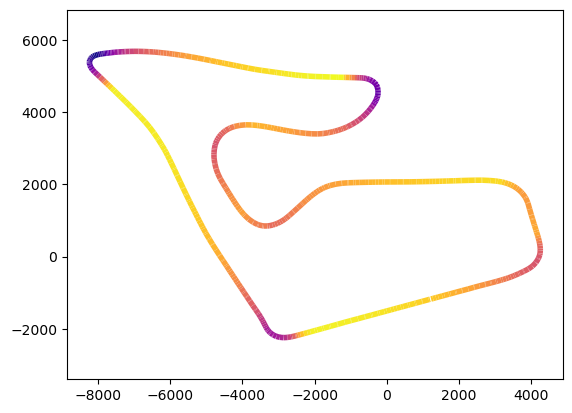

In [4]:
x = np.array(tel['X'].values)
y = np.array(tel['Y'].values)
color = lap.telemetry['Speed']
colormap = mpl.cm.plasma

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = plt.Normalize(color.min(),color.max())
lc_comp = LineCollection(segments, norm=norm, cmap=colormap)
lc_comp.set_array(color)
lc_comp.set_linewidth(4)

plt.gca().add_collection(lc_comp)
plt.axis('equal')


plt.show()

In [91]:
pd.DataFrame(tel)

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2021-07-03 13:52:43.255,0 days 01:07:16.840000,,429.534722,0 days 00:00:00,10706,293,8,100,False,12,interpolation,0.093493,0.000022,OnTrack,1193.471541,-1182.730471,7214.980785
3,2021-07-03 13:52:43.300,0 days 01:07:16.885000,,429.534722,0 days 00:00:00.045000,10718,294,8,100,False,12,pos,3.783333,0.000878,OnTrack,1159.000000,-1192.000000,7215.000000
4,2021-07-03 13:52:43.520,0 days 01:07:17.105000,,429.534722,0 days 00:00:00.265000,10739,295,8,100,False,12,pos,21.924825,0.005090,OnTrack,985.000000,-1239.000000,7215.000000
5,2021-07-03 13:52:43.540,0 days 01:07:17.125000,77,429.534722,0 days 00:00:00.285000,10761,297,8,100,False,12,car,23.583333,0.005475,OnTrack,969.040430,-1243.341187,7214.939667
6,2021-07-03 13:52:43.740,0 days 01:07:17.325000,77,424.501389,0 days 00:00:00.485000,10815,298,8,100,False,12,pos,40.244841,0.009344,OnTrack,809.000000,-1287.000000,7214.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,2021-07-03 13:53:46.540,0 days 01:08:20.125000,77,408.156667,0 days 00:01:03.285000,11640,287,7,100,False,12,car,4268.278889,0.990976,OnTrack,1533.009173,-1091.374912,7215.524579
549,2021-07-03 13:53:46.681,0 days 01:08:20.266000,77,404.056667,0 days 00:01:03.426000,11702,288,7,100,False,12,pos,4279.614223,0.993608,OnTrack,1425.000000,-1120.000000,7215.000000
550,2021-07-03 13:53:46.780,0 days 01:08:20.365000,77,399.956667,0 days 00:01:03.525000,11764,290,7,100,False,12,car,4287.612222,0.995465,OnTrack,1357.829129,-1138.523365,7214.927715
551,2021-07-03 13:53:46.901,0 days 01:08:20.486000,77,399.956667,0 days 00:01:03.646000,11770,291,7,100,False,12,pos,4297.434742,0.997745,OnTrack,1277.000000,-1161.000000,7215.000000


In [92]:
df_tel = pd.DataFrame(tel)
df_tel.to_pickle('telemetry')

color.to_pickle('lap_color')

In [1]:
import plotly as plt
import plotly.graph_objects as go
import numpy as np

t = np.linspace(0, 10, 1000)
x, y = t, np.cos(t)

data = go.Scatter(x=x, y=y, mode='markers', marker={'color': x, 'colorscale': 'Rainbow', 'size': 10})

layout = dict(plot_bgcolor='white', margin=dict(t=0, b=0, r=0, l=0, pad=0),
              xaxis=dict(showgrid=False, zeroline=False, mirror=True, linecolor='gray'),
              yaxis=dict(showgrid=False, zeroline=False, mirror=True, linecolor='gray'))

fig = go.Figure(data=data, layout=layout)

fig.show()


In [8]:

session = fastf1.get_session(2021, 10, 'Q')
session.load()
session

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.4.4]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

2021 Season Round 10: British Grand Prix - Qualifying

In [9]:
lap = session.laps.pick_fastest()
lap

Time                      0 days 00:54:24.158000
Driver                                       HAM
DriverNumber                                  44
LapTime                   0 days 00:01:26.023000
LapNumber                                   15.0
Stint                                        4.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:27.295000
Sector2Time               0 days 00:00:34.977000
Sector3Time               0 days 00:00:23.751000
Sector1SessionTime        0 days 00:53:25.430000
Sector2SessionTime        0 days 00:54:00.407000
Sector3SessionTime        0 days 00:54:24.158000
SpeedI1                                    314.0
SpeedI2                                    272.0
SpeedFL                                    254.0
SpeedST                                    322.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [76]:
import pandas as pd
import sklearn

df = pd.read_csv('car_spec_extend.csv', encoding='unicode_escape')
df = df.replace(',', '', regex=True)

cols = ["Weight_kg","HP","Height_mm","Drag_coefficient","Frontal area_m2","Corners","Straights","Distance"]
resp = ["Time_s"]

tracks = list(df['Track'].unique())

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Car_type          223 non-null    object 
 1   Weight_kg         223 non-null    float64
 2   HP                223 non-null    float64
 3   Height_mm         223 non-null    float64
 4   Drag_coefficient  223 non-null    float64
 5   Frontal area_m2   223 non-null    float64
 6   Track             223 non-null    object 
 7   Corners           223 non-null    float64
 8   Straights         223 non-null    float64
 9   Distance          222 non-null    float64
 10  Time_s            223 non-null    float64
dtypes: float64(9), object(2)
memory usage: 19.3+ KB


In [139]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

X = df[cols]
y = df[resp]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostRegressor(iterations=1000,
                          learning_rate=0.5,
                          l2_leaf_reg=3,
                          depth=5)

model.fit(X_train, y_train)

0:	learn: 103.5824676	total: 836us	remaining: 836ms
1:	learn: 66.5742110	total: 2.31ms	remaining: 1.15s
2:	learn: 42.5140186	total: 2.74ms	remaining: 911ms
3:	learn: 27.7885149	total: 4.67ms	remaining: 1.16s
4:	learn: 22.7037587	total: 5.39ms	remaining: 1.07s
5:	learn: 17.5596804	total: 5.96ms	remaining: 987ms
6:	learn: 15.5693055	total: 6.53ms	remaining: 926ms
7:	learn: 13.6466628	total: 8.71ms	remaining: 1.08s
8:	learn: 11.8825764	total: 9.56ms	remaining: 1.05s
9:	learn: 10.6710165	total: 10.1ms	remaining: 1s
10:	learn: 9.4659622	total: 10.7ms	remaining: 963ms
11:	learn: 8.9334514	total: 11.3ms	remaining: 929ms
12:	learn: 8.1371662	total: 11.8ms	remaining: 900ms
13:	learn: 7.7052627	total: 12.5ms	remaining: 883ms
14:	learn: 7.4693205	total: 13.2ms	remaining: 865ms
15:	learn: 7.3712684	total: 14.9ms	remaining: 916ms
16:	learn: 7.2976176	total: 15.5ms	remaining: 898ms
17:	learn: 6.7945127	total: 16.1ms	remaining: 881ms
18:	learn: 6.0584956	total: 16.7ms	remaining: 865ms
19:	learn: 5.91

120:	learn: 0.5732507	total: 160ms	remaining: 1.16s
121:	learn: 0.5627230	total: 161ms	remaining: 1.16s
122:	learn: 0.5535347	total: 161ms	remaining: 1.15s
123:	learn: 0.5531168	total: 162ms	remaining: 1.14s
124:	learn: 0.5459972	total: 166ms	remaining: 1.16s
125:	learn: 0.5379538	total: 166ms	remaining: 1.15s
126:	learn: 0.5331205	total: 166ms	remaining: 1.14s
127:	learn: 0.5328431	total: 192ms	remaining: 1.31s
128:	learn: 0.5277179	total: 193ms	remaining: 1.3s
129:	learn: 0.5167236	total: 193ms	remaining: 1.29s
130:	learn: 0.5124707	total: 194ms	remaining: 1.29s
131:	learn: 0.5104703	total: 195ms	remaining: 1.28s
132:	learn: 0.5101021	total: 196ms	remaining: 1.28s
133:	learn: 0.4955539	total: 197ms	remaining: 1.27s
134:	learn: 0.4890328	total: 197ms	remaining: 1.26s
135:	learn: 0.4833301	total: 197ms	remaining: 1.25s
136:	learn: 0.4733844	total: 198ms	remaining: 1.25s
137:	learn: 0.4685122	total: 201ms	remaining: 1.25s
138:	learn: 0.4667086	total: 202ms	remaining: 1.25s
139:	learn: 0

In [143]:
import plotly.express as px

# Make predictions
predictions = model.predict(X_val)

# Create a DataFrame with actual and predicted values
obs = y_val.values.flatten()
results = pd.DataFrame({'Actual': obs, 'Predicted': predictions})

# Plot scatter plot of Actual vs Predicted values
fig = px.scatter(results, x='Actual', y='Predicted',
                 title='Actual vs Predicted Values',
                 labels={'Actual': 'Actual Values', 'Predicted': 'Predicted Values'},
                 trendline='ols')

fig.show()

results.to_pickle("lap_time_model_results")


In [147]:
w = list(range(500,2000,100))

xhat = list(X_train.iloc[2,:].values)
xhat = [xhat for x in  range(len(w))]
df_range = pd.DataFrame(xhat,columns=cols)
df_range['Weight_kg'] = w
predictions = model.predict(df_range)
predictions

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_range['Weight_kg'],y=predictions))
fig.show()


In [144]:
import math
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score

mse = mean_squared_error(obs, predictions)
r2 = r2_score(obs, predictions)
explained_variance = explained_variance_score(obs, predictions)
rmse = math.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R^2): {r2:.4f}")
print(f"Explained Variance Score: {explained_variance:.4f}")

Mean Squared Error (MSE): 100.4727
Root Mean Squared Error (RMSE): 10.0236
R-squared (R^2): 0.9951
Explained Variance Score: 0.9951


In [145]:
model.save_model("lap_time_model")


In [146]:
df

,Car_type,Weight_kg,HP,Height_mm,Drag_coefficient,Frontal area_m2,Track,Corners,Straights,Distance,Time_s
0,McLaren P1,1519.0,916.0,1240.0,0.36,1.12,Silverstone_national,18.0,3.0,2.639,58.24
1,Porsche 918 Spyder,1671.0,887.0,1230.0,0.35,1.15,Silverstone_national,18.0,3.0,2.639,58.47
2,Ferrari LaFerrari,1606.0,963.0,1195.0,0.34,1.10,Silverstone_national,18.0,3.0,2.639,58.58
3,Porsche 911 GT3 RS (991),1469.0,500.0,1275.0,0.39,1.20,Silverstone_national,18.0,3.0,2.639,60.00
4,Porsche Cayman GT4 (981),1360.0,385.0,1225.0,0.37,1.08,Silverstone_national,18.0,3.0,2.639,63.20
...,...,...,...,...,...,...,...,...,...,...,...
218,Renault Clio 182 Trophy,1090.0,182.0,1200.0,0.34,1.08,Snetterton Circuit,13.0,3.0,4.760,324.00
219,VW Golf GTI (Mk V),1408.0,200.0,1400.0,0.36,1.10,Snetterton Circuit,13.0,3.0,4.760,325.00
220,Ford Fiesta ST,1147.0,150.0,1300.0,0.35,1.09,Snetterton Circuit,13.0,3.0,4.760,326.00
221,BMW 328i Coupe,1456.0,193.0,1400.0,0.36,1.11,Snetterton Circuit,13.0,3.0,4.760,327.00
